# n이 아닌 n-1로 보정 

- 모집단의 편차 제곱 합과 표본에서의 편차 제곱의 합의 비율은 $\frac{n-1}{n}$ 임이 증명 됨. 
- 표본 분산
$$s^2 = \left( \frac{\sum (x_i - \bar{x})^2}{n} \right) \times \frac{n}{n-1} = \frac{\sum (x_i - \bar{x})^2}{n-1}$$

- 과소평가되던 표본 분산($s^2$)의 덩치가 살짝 커지면서, 우리가 알고 싶었던 진짜 모집단의 분산($\sigma^2$)과 기가 막히게 일치하게 되는 것

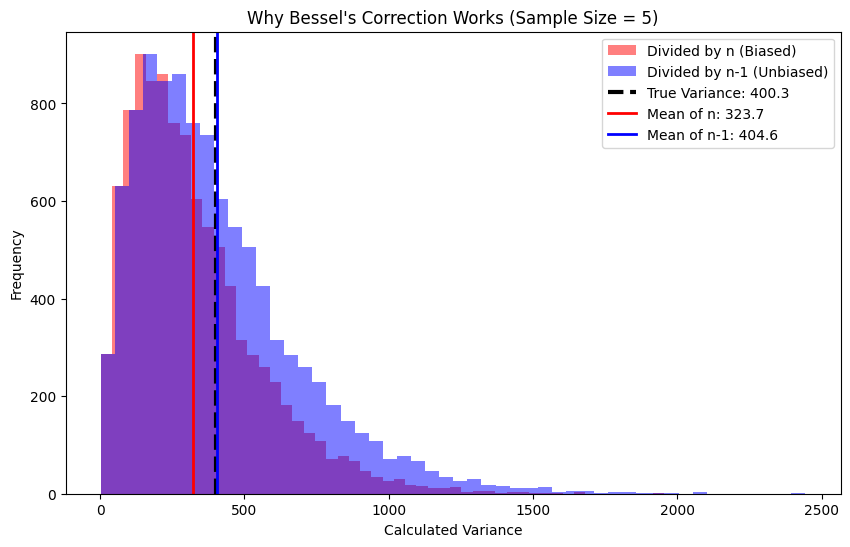

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 거대한 모집단 생성 (우리가 알고 싶은 '진짜' 분산)
# 평균 100, 표준편차 20인 10만 명의 데이터
population = np.random.normal(100, 20, 100000) 
true_variance = np.var(population) # 실제 모집단의 분산 (약 400)

sample_size = 5 # 겨우 5명만 뽑아보는 극한의 상황
n_variances = []
n_minus_1_variances = []

# 2. 5명씩 뽑아서 분산을 계산하는 짓을 10,000번 반복해 봅니다!
for _ in range(10000): 
    sample = np.random.choice(population, sample_size)
    
    # n으로 나눈 분산 (NumPy의 기본값, ddof=0)
    var_n = np.var(sample, ddof=0) 
    # n-1로 나눈 분산 (Bessel's correction, ddof=1), pandas.DataFrame.var()의 기본값 n-1과 동일
    var_n_minus_1 = np.var(sample, ddof=1)
    
    n_variances.append(var_n)
    n_minus_1_variances.append(var_n_minus_1)

# 3. 시각화
plt.figure(figsize=(10, 6))
plt.hist(n_variances, bins=50, alpha=0.5, label='Divided by n (Biased)', color='red')
plt.hist(n_minus_1_variances, bins=50, alpha=0.5, label='Divided by n-1 (Unbiased)', color='blue')

# 평균 선 그리기
plt.axvline(true_variance, color='black', linestyle='dashed', linewidth=3, label=f'True Variance: {true_variance:.1f}')
plt.axvline(np.mean(n_variances), color='red', linestyle='solid', linewidth=2, label=f'Mean of n: {np.mean(n_variances):.1f}')
plt.axvline(np.mean(n_minus_1_variances), color='blue', linestyle='solid', linewidth=2, label=f'Mean of n-1: {np.mean(n_minus_1_variances):.1f}')

plt.title("Why Bessel's Correction Works (Sample Size = 5)")
plt.xlabel('Calculated Variance')
plt.ylabel('Frequency')
plt.legend()
plt.show()